# 07 — Patch extraction for T3-Climate tensors

**Project:** `Barranquilla_LST_2013_2026_Modeling`  
**Repository notebook:** `notebooks/07_patch_extraction.ipynb`  
**Operational target years:** 2016–2025  
**Input tensor product:** full-domain T3 spectral + NASA POWER climate tensors from Notebook 06  
**Final model name:** `T3-Climate ConvLSTM-SE U-Net model`

This notebook extracts training, validation, and test patches from the full-domain tensors produced by `06_tensor_construction.ipynb`.

The patch product contains:

```text
18 spectral T3 channels + 2 NASA POWER climate channels = 20 input channels
```

The NASA POWER channels are annual regional descriptors replicated spatially for tensor compatibility. They must not be interpreted as pixel-wise climate rasters.

**Important experimental distinction**

The patches generated here correspond to the final climate-augmented model. The spectral-only models M1–M4 use spectral-only T3 patches. This separation avoids conflating architecture effects with climate-augmentation effects.

### Reference-experiment traceability

Notebook 06→07 is the public reconstruction of the logical and tensor contract used by the reported experiment: T3 temporal ordering, predictor-channel content, target-year split, patch geometry, and validity rules. The large historical patch arrays used in the reference M1–M5 runs are not stored in GitHub, and this public reconstruction is not asserted to reproduce those binary NPZ artifacts byte for byte.

Training notebooks 08A–08D consume the archived reference-experiment product `T3_full` (18 spectral channels). Notebook 08E consumes the archived product `T3_full_M5B_delta_t2m_delta_radiation` (20 channels: the same 18 spectral T3 channels plus the two selected climate-radiative descriptors). These historical product names are retained as provenance identifiers for the runs reported in the manuscript.

Accordingly, the Notebook 06→07 chain should be interpreted as a reproducible reconstruction of the data contract and processing logic, not as evidence that newly generated patch files are the identical binary artifacts used in the historical training runs.


In [2]:
# ============================================================
# CELL 1 — Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# ============================================================
# CELL 2 — Imports and official paths
# ============================================================

from pathlib import Path
from datetime import datetime
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.errors import NotGeoreferencedWarning

warnings.filterwarnings('ignore', category=NotGeoreferencedWarning)
pd.set_option('display.max_columns', 160)

PROJECT_DIR = Path('/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling')
MODEL_DOMAIN_REFERENCE = PROJECT_DIR / '01_aoi_reference' / 'reference_grid' / 'model_domain_reference.tif'

# Full-domain tensors produced by Notebook 06.
SOURCE_TENSOR_ROOT = PROJECT_DIR / '06_model_inputs' / 'tensors' / 'T3_M5B_spectral_nasa_power'
SOURCE_TENSOR_NPZ_DIR = SOURCE_TENSOR_ROOT / 'npz'
DOC06_DIR = PROJECT_DIR / '00_documentation' / 'quality_control' / '06_tensor_construction_2016_2025'
SOURCE_TENSOR_MANIFEST = DOC06_DIR / '06_tensor_manifest_T3_M5B_2016_2025.csv'
SOURCE_CHANNEL_SCHEMA = DOC06_DIR / '06_tensor_channel_schema_T3_M5B_2016_2025.csv'

# Patch outputs. Heavy NPZ files remain in Drive and must not be uploaded to GitHub.
PATCH_PRODUCT_NAME = 'T3_spectral_climate_nasa_power'
PATCH_ROOT = PROJECT_DIR / '06_model_inputs' / 'patches' / PATCH_PRODUCT_NAME
PATCH_NPZ_DIR = PATCH_ROOT / 'npz'
PATCH_METADATA_DIR = PATCH_ROOT / 'metadata'

# Lightweight documentation outputs for GitHub.
DOC07_DIR = PROJECT_DIR / '00_documentation' / 'quality_control' / '07_patch_extraction_2016_2025'
DOC07_FIG_DIR = DOC07_DIR / 'figures'

for d in [PATCH_NPZ_DIR, PATCH_METADATA_DIR, DOC07_DIR, DOC07_FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

required_paths = {
    'PROJECT_DIR': PROJECT_DIR,
    'MODEL_DOMAIN_REFERENCE': MODEL_DOMAIN_REFERENCE,
    'SOURCE_TENSOR_NPZ_DIR': SOURCE_TENSOR_NPZ_DIR,
    'SOURCE_TENSOR_MANIFEST': SOURCE_TENSOR_MANIFEST,
    'SOURCE_CHANNEL_SCHEMA': SOURCE_CHANNEL_SCHEMA,
}
missing = {k: str(v) for k, v in required_paths.items() if not Path(v).exists()}
if missing:
    raise FileNotFoundError('Missing required paths: ' + json.dumps(missing, indent=2, ensure_ascii=False))

with rasterio.open(MODEL_DOMAIN_REFERENCE) as ref:
    REFERENCE_HEIGHT = ref.height
    REFERENCE_WIDTH = ref.width
    REFERENCE_CRS = str(ref.crs)
    REFERENCE_TRANSFORM = ref.transform
    REFERENCE_BOUNDS = ref.bounds

print('PROJECT_DIR           :', PROJECT_DIR)
print('SOURCE_TENSOR_MANIFEST:', SOURCE_TENSOR_MANIFEST)
print('PATCH_ROOT            :', PATCH_ROOT)
print('DOC07_DIR             :', DOC07_DIR)
print('Reference shape       :', (REFERENCE_HEIGHT, REFERENCE_WIDTH))
print('Reference CRS         :', REFERENCE_CRS)


PROJECT_DIR           : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling
SOURCE_TENSOR_MANIFEST: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/06_tensor_construction_2016_2025/06_tensor_manifest_T3_M5B_2016_2025.csv
PATCH_ROOT            : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/patches/T3_spectral_climate_nasa_power
DOC07_DIR             : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/07_patch_extraction_2016_2025
Reference shape       : (1115, 1257)
Reference CRS         : EPSG:32618


In [4]:
# ============================================================
# CELL 3 — Patch extraction design
# ============================================================

PATCH_SIZE = 128

# Train uses overlap to increase sample density.
# Validation and test use a systematic non-overlapping grid for reproducibility.
STRIDE_BY_SPLIT = {
    'train': 64,
    'validation': 128,
    'test': 128,
}

MIN_VALID_FRACTION_BY_SPLIT = {
    'train': 0.70,
    'validation': 0.70,
    'test': 0.70,
}

TARGET_YEARS = list(range(2016, 2026))  # Python stop is exclusive: 2016–2025, excluding 2026.
TRAIN_YEARS = [2016, 2017, 2018, 2019]
VALIDATION_YEARS = [2020, 2021, 2022]
TEST_YEARS = [2023, 2024, 2025]
SPLITS = {'train': TRAIN_YEARS, 'validation': VALIDATION_YEARS, 'test': TEST_YEARS}
YEAR_TO_SPLIT = {year: split for split, years in SPLITS.items() for year in years}

EXPECTED_CHANNELS = 20
EXPECTED_Y_CHANNELS = 1
EXPECTED_MASK_CHANNELS = 1
RANDOM_SEED = 20260623

np.random.seed(RANDOM_SEED)

print('PATCH_SIZE:', PATCH_SIZE)
print('STRIDE_BY_SPLIT:', STRIDE_BY_SPLIT)
print('MIN_VALID_FRACTION_BY_SPLIT:', MIN_VALID_FRACTION_BY_SPLIT)
print('TARGET_YEARS:', TARGET_YEARS)
print('EXPECTED_CHANNELS:', EXPECTED_CHANNELS)


PATCH_SIZE: 128
STRIDE_BY_SPLIT: {'train': 64, 'validation': 128, 'test': 128}
MIN_VALID_FRACTION_BY_SPLIT: {'train': 0.7, 'validation': 0.7, 'test': 0.7}
TARGET_YEARS: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
EXPECTED_CHANNELS: 20


In [5]:
# ============================================================
# CELL 4 — Load tensor manifest and channel schema
# ============================================================

manifest_df = pd.read_csv(SOURCE_TENSOR_MANIFEST)
channel_schema_df = pd.read_csv(SOURCE_CHANNEL_SCHEMA)

# Defensive cleanup.
manifest_df.columns = [c.strip() for c in manifest_df.columns]
channel_schema_df.columns = [c.strip() for c in channel_schema_df.columns]

required_manifest_cols = {'target_year', 'split', 'npz_path', 'n_channels', 'valid_fraction'}
missing_manifest_cols = required_manifest_cols - set(manifest_df.columns)
if missing_manifest_cols:
    raise RuntimeError(f'Missing columns in tensor manifest: {missing_manifest_cols}')

manifest_df['target_year'] = manifest_df['target_year'].astype(int)
manifest_df = manifest_df.sort_values('target_year').reset_index(drop=True)

expected_years = set(TARGET_YEARS)
found_years = set(manifest_df['target_year'].tolist())
if found_years != expected_years:
    raise RuntimeError(f'Unexpected target years in manifest. Found={sorted(found_years)}, Expected={sorted(expected_years)}')

for year, split in YEAR_TO_SPLIT.items():
    manifest_split = manifest_df.loc[manifest_df['target_year'] == year, 'split'].iloc[0]
    if manifest_split != split:
        raise RuntimeError(f'Split mismatch for {year}: manifest={manifest_split}, expected={split}')

if not (manifest_df['n_channels'].astype(int) == EXPECTED_CHANNELS).all():
    raise RuntimeError('At least one source tensor does not have 20 channels.')

missing_npz = [p for p in manifest_df['npz_path'].tolist() if not Path(p).exists()]
if missing_npz:
    raise FileNotFoundError('Missing tensor NPZ files:\n' + '\n'.join(missing_npz[:20]))

print('Source tensor manifest rows:', len(manifest_df))
display(manifest_df)
print('Channel schema rows:', len(channel_schema_df))
display(channel_schema_df)


Source tensor manifest rows: 10


,target_year,split,npz_path,mask_tif_path,X_shape,y_shape,mask_shape,n_channels,valid_pixels,total_pixels,valid_fraction,X_dtype,y_dtype,mask_dtype,has_nan_X,has_nan_y,mask_unique
0,2016,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,903234,1401555,0.644451,float32,float32,uint8,False,False,"0,1"
1,2017,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,903568,1401555,0.644690,float32,float32,uint8,False,False,"0,1"
2,2018,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,903114,1401555,0.644366,float32,float32,uint8,False,False,"0,1"
3,2019,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,904658,1401555,0.645467,float32,float32,uint8,False,False,"0,1"
4,2020,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,905110,1401555,0.645790,float32,float32,uint8,False,False,"0,1"
5,2021,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,906573,1401555,0.646834,float32,float32,uint8,False,False,"0,1"
6,2022,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,907119,1401555,0.647223,float32,float32,uint8,False,False,"0,1"
7,2023,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,906407,1401555,0.646715,float32,float32,uint8,False,False,"0,1"
8,2024,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,906209,1401555,0.646574,float32,float32,uint8,False,False,"0,1"
9,2025,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,906233,1401555,0.646591,float32,float32,uint8,False,False,"0,1"


Channel schema rows: 20


,channel_index,channel_name,channel_group,source,spatial_interpretation
0,0,NDVI_Yminus3,spectral_T3,Landsat normalized annual raster,pixel-wise raster
1,1,NDMI_Yminus3,spectral_T3,Landsat normalized annual raster,pixel-wise raster
2,2,NDBI_Yminus3,spectral_T3,Landsat normalized annual raster,pixel-wise raster
3,3,UI_Yminus3,spectral_T3,Landsat normalized annual raster,pixel-wise raster
4,4,SAVI_Yminus3,spectral_T3,Landsat normalized annual raster,pixel-wise raster
5,5,BSI_Yminus3,spectral_T3,Landsat normalized annual raster,pixel-wise raster
6,6,NDVI_Yminus2,spectral_T3,Landsat normalized annual raster,pixel-wise raster
7,7,NDMI_Yminus2,spectral_T3,Landsat normalized annual raster,pixel-wise raster
8,8,NDBI_Yminus2,spectral_T3,Landsat normalized annual raster,pixel-wise raster
9,9,UI_Yminus2,spectral_T3,Landsat normalized annual raster,pixel-wise raster


In [6]:
# ============================================================
# CELL 5 — NPZ loading and validation utilities
# ============================================================

def _as_python_scalar(x):
    arr = np.asarray(x)
    if arr.shape == ():
        return arr.item()
    if arr.size == 1:
        return arr.reshape(-1)[0].item()
    return arr.tolist()


def load_tensor_npz(npz_path: Path):
    '''Load a full-domain tensor sample created by Notebook 06.'''
    npz_path = Path(npz_path)
    with np.load(npz_path, allow_pickle=False) as data:
        X = data['X'].astype(np.float32)
        y = data['y'].astype(np.float32)
        mask = data['mask'].astype(np.uint8)
        channel_names = data['channel_names'].astype(str).tolist()
        target_year = int(_as_python_scalar(data['target_year'])) if 'target_year' in data.files else None
        split = str(_as_python_scalar(data['split'])) if 'split' in data.files else None
    return X, y, mask, channel_names, target_year, split


def validate_tensor_shapes(X, y, mask, channel_names, label=''):
    if X.ndim != 3:
        raise RuntimeError(f'{label}: X must be H×W×C. Found {X.shape}')
    if y.ndim != 3:
        raise RuntimeError(f'{label}: y must be H×W×1. Found {y.shape}')
    if mask.ndim != 3:
        raise RuntimeError(f'{label}: mask must be H×W×1. Found {mask.shape}')
    if X.shape[:2] != y.shape[:2] or X.shape[:2] != mask.shape[:2]:
        raise RuntimeError(f'{label}: spatial mismatch. X={X.shape}, y={y.shape}, mask={mask.shape}')
    if X.shape[-1] != EXPECTED_CHANNELS:
        raise RuntimeError(f'{label}: expected {EXPECTED_CHANNELS} channels, found {X.shape[-1]}')
    if y.shape[-1] != EXPECTED_Y_CHANNELS:
        raise RuntimeError(f'{label}: y must have 1 channel. Found {y.shape[-1]}')
    if mask.shape[-1] != EXPECTED_MASK_CHANNELS:
        raise RuntimeError(f'{label}: mask must have 1 channel. Found {mask.shape[-1]}')
    if len(channel_names) != EXPECTED_CHANNELS:
        raise RuntimeError(f'{label}: expected {EXPECTED_CHANNELS} channel names, found {len(channel_names)}')
    if not np.isfinite(X).all():
        raise RuntimeError(f'{label}: X contains NaN or inf.')
    if not np.isfinite(y).all():
        raise RuntimeError(f'{label}: y contains NaN or inf.')
    mask_unique = sorted(np.unique(mask).tolist())
    if not set(mask_unique).issubset({0, 1}):
        raise RuntimeError(f'{label}: mask must be binary. Found {mask_unique}')


# Smoke-test the first source tensor.
first_row = manifest_df.iloc[0]
X0, y0, mask0, ch0, year0, split0 = load_tensor_npz(Path(first_row['npz_path']))
validate_tensor_shapes(X0, y0, mask0, ch0, label=f'target_year={year0}')

print('First tensor loaded successfully')
print('Year/split:', year0, split0)
print('X:', X0.shape, X0.dtype)
print('y:', y0.shape, y0.dtype)
print('mask:', mask0.shape, mask0.dtype)
print('channels:', ch0)


First tensor loaded successfully
Year/split: 2016 train
X: (1115, 1257, 20) float32
y: (1115, 1257, 1) float32
mask: (1115, 1257, 1) uint8
channels: ['NDVI_Yminus3', 'NDMI_Yminus3', 'NDBI_Yminus3', 'UI_Yminus3', 'SAVI_Yminus3', 'BSI_Yminus3', 'NDVI_Yminus2', 'NDMI_Yminus2', 'NDBI_Yminus2', 'UI_Yminus2', 'SAVI_Yminus2', 'BSI_Yminus2', 'NDVI_Yminus1', 'NDMI_Yminus1', 'NDBI_Yminus1', 'UI_Yminus1', 'SAVI_Yminus1', 'BSI_Yminus1', 'clim_delta_t2m_mean_Y_minus_Yminus1_ztrain', 'clim_delta_solar_radiation_mean_Y_minus_Yminus1_ztrain']


In [7]:
# ============================================================
# CELL 6 — Patch window and extraction utilities
# ============================================================

def generate_patch_windows(height: int, width: int, patch_size: int, stride: int):
    '''Generate top-left patch windows while explicitly including bottom/right edges.'''
    if height < patch_size or width < patch_size:
        raise RuntimeError(f'Image smaller than patch_size. H={height}, W={width}, P={patch_size}')

    rows = list(range(0, height - patch_size + 1, stride))
    cols = list(range(0, width - patch_size + 1, stride))

    last_row = height - patch_size
    last_col = width - patch_size
    if rows[-1] != last_row:
        rows.append(last_row)
    if cols[-1] != last_col:
        cols.append(last_col)

    return [(r0, c0, r0 + patch_size, c0 + patch_size) for r0 in rows for c0 in cols]


def extract_valid_patches_from_tensor(
    X,
    y,
    mask,
    target_year: int,
    split: str,
    patch_size: int,
    stride: int,
    min_valid_fraction: float,
):
    '''Extract valid patches from one full-domain annual tensor.'''
    h, w, c = X.shape
    windows = generate_patch_windows(h, w, patch_size, stride)

    X_list, y_list, mask_list, rows = [], [], [], []

    for candidate_window_id, (r0, c0, r1, c1) in enumerate(windows):
        patch_mask = mask[r0:r1, c0:c1, :]
        valid_fraction = float(patch_mask[..., 0].mean())
        if valid_fraction < min_valid_fraction:
            continue

        patch_X = X[r0:r1, c0:c1, :]
        patch_y = y[r0:r1, c0:c1, :]

        if patch_X.shape != (patch_size, patch_size, EXPECTED_CHANNELS):
            raise RuntimeError(f'Patch X has unexpected shape: {patch_X.shape}')
        if patch_y.shape != (patch_size, patch_size, 1):
            raise RuntimeError(f'Patch y has unexpected shape: {patch_y.shape}')
        if patch_mask.shape != (patch_size, patch_size, 1):
            raise RuntimeError(f'Patch mask has unexpected shape: {patch_mask.shape}')

        mask_bool = patch_mask[..., 0].astype(bool)
        if mask_bool.sum() == 0:
            continue
        if not np.isfinite(patch_X[mask_bool]).all():
            raise RuntimeError(f'NaN/inf in X inside mask: year={target_year}, row={r0}, col={c0}')
        if not np.isfinite(patch_y[..., 0][mask_bool]).all():
            raise RuntimeError(f'NaN/inf in y inside mask: year={target_year}, row={r0}, col={c0}')

        accepted_patch_id = len(X_list)
        X_list.append(patch_X.astype(np.float32))
        y_list.append(patch_y.astype(np.float32))
        mask_list.append(patch_mask.astype(np.uint8))

        y_vals = patch_y[..., 0][mask_bool]
        rows.append({
            'target_year': int(target_year),
            'split': split,
            'accepted_patch_id_in_year': int(accepted_patch_id),
            'candidate_window_id': int(candidate_window_id),
            'row0': int(r0),
            'col0': int(c0),
            'row1': int(r1),
            'col1': int(c1),
            'patch_size': int(patch_size),
            'stride': int(stride),
            'min_valid_fraction_threshold': float(min_valid_fraction),
            'valid_pixels': int(mask_bool.sum()),
            'total_pixels': int(patch_size * patch_size),
            'valid_fraction': float(valid_fraction),
            'y_mean_inside_mask': float(np.mean(y_vals)),
            'y_std_inside_mask': float(np.std(y_vals)),
            'y_min_inside_mask': float(np.min(y_vals)),
            'y_max_inside_mask': float(np.max(y_vals)),
        })

    if not X_list:
        return (
            np.empty((0, patch_size, patch_size, EXPECTED_CHANNELS), dtype=np.float32),
            np.empty((0, patch_size, patch_size, 1), dtype=np.float32),
            np.empty((0, patch_size, patch_size, 1), dtype=np.uint8),
            rows,
        )

    return np.stack(X_list), np.stack(y_list), np.stack(mask_list), rows


# Window counts before filtering.
H, W, C = X0.shape
for split, stride in STRIDE_BY_SPLIT.items():
    windows = generate_patch_windows(H, W, PATCH_SIZE, stride)
    print(f'split={split:10s} | stride={stride:3d} | n_windows_before_filter={len(windows)}')


split=train      | stride= 64 | n_windows_before_filter=323
split=validation | stride=128 | n_windows_before_filter=90
split=test       | stride=128 | n_windows_before_filter=90


In [8]:
# ============================================================
# CELL 7 — Extract annual patches and save annual NPZ files
# ============================================================

annual_patch_manifest_rows = []
annual_qc_rows = []

for _, row in manifest_df.iterrows():
    target_year = int(row['target_year'])
    split = row['split']
    npz_path = Path(row['npz_path'])

    stride = STRIDE_BY_SPLIT[split]
    min_valid_fraction = MIN_VALID_FRACTION_BY_SPLIT[split]

    print('\n' + '=' * 80)
    print(f'Extracting patches: target_year={target_year}, split={split}')
    print('=' * 80)

    X, y, mask, channel_names, npz_year, npz_split = load_tensor_npz(npz_path)
    validate_tensor_shapes(X, y, mask, channel_names, label=f'target_year={target_year}')

    if npz_year is not None and int(npz_year) != target_year:
        raise RuntimeError(f'NPZ target year mismatch: manifest={target_year}, npz={npz_year}')
    if npz_split is not None and str(npz_split) != split:
        raise RuntimeError(f'NPZ split mismatch: manifest={split}, npz={npz_split}')

    X_p, y_p, mask_p, patch_rows = extract_valid_patches_from_tensor(
        X=X,
        y=y,
        mask=mask,
        target_year=target_year,
        split=split,
        patch_size=PATCH_SIZE,
        stride=stride,
        min_valid_fraction=min_valid_fraction,
    )

    n_patches = int(X_p.shape[0])
    if n_patches == 0:
        raise RuntimeError(
            f'No patches extracted for year={target_year}, split={split}. '
            f'Check min_valid_fraction={min_valid_fraction}.'
        )

    out_npz = PATCH_NPZ_DIR / f'T3_Climate_patches_target_{target_year}_{split}.npz'

    np.savez_compressed(
        out_npz,
        X=X_p,
        y=y_p,
        mask=mask_p,
        channel_names=np.array(channel_names),
        target_year=np.full((n_patches,), target_year, dtype=np.int16),
        split=np.array(split),
        patch_size=np.array(PATCH_SIZE, dtype=np.int16),
        stride=np.array(stride, dtype=np.int16),
        min_valid_fraction=np.array(min_valid_fraction, dtype=np.float32),
        source_tensor_npz=np.array(str(npz_path)),
    )

    for pr in patch_rows:
        pr['patch_npz_path'] = str(out_npz)
        pr['source_tensor_npz_path'] = str(npz_path)
    annual_patch_manifest_rows.extend(patch_rows)

    valid_fracs = np.array([r['valid_fraction'] for r in patch_rows], dtype=np.float32)
    y_means = np.array([r['y_mean_inside_mask'] for r in patch_rows], dtype=np.float32)
    y_stds = np.array([r['y_std_inside_mask'] for r in patch_rows], dtype=np.float32)

    annual_qc_rows.append({
        'target_year': target_year,
        'split': split,
        'source_tensor_npz_path': str(npz_path),
        'patch_npz_path': str(out_npz),
        'n_patches': n_patches,
        'patch_size': int(PATCH_SIZE),
        'stride': int(stride),
        'min_valid_fraction_threshold': float(min_valid_fraction),
        'valid_fraction_min': float(valid_fracs.min()),
        'valid_fraction_mean': float(valid_fracs.mean()),
        'valid_fraction_max': float(valid_fracs.max()),
        'y_patch_mean_mean': float(y_means.mean()),
        'y_patch_mean_std': float(y_means.std()),
        'y_patch_mean_min': float(y_means.min()),
        'y_patch_mean_max': float(y_means.max()),
        'y_patch_std_mean': float(y_stds.mean()),
        'X_shape': str(X_p.shape),
        'y_shape': str(y_p.shape),
        'mask_shape': str(mask_p.shape),
        'n_channels': int(X_p.shape[-1]),
        'has_nan_X': bool(np.isnan(X_p).any()),
        'has_nan_y': bool(np.isnan(y_p).any()),
        'mask_unique': ','.join(map(str, sorted(np.unique(mask_p).tolist()))),
    })

    print(f'Saved annual patch NPZ: {out_npz}')
    print(f'n_patches={n_patches}, valid_fraction_mean={valid_fracs.mean():.4f}')

patch_manifest_df = pd.DataFrame(annual_patch_manifest_rows)
annual_qc_df = pd.DataFrame(annual_qc_rows)

patch_manifest_csv = DOC07_DIR / '07_patch_manifest_T3_Climate_2016_2025.csv'
annual_qc_csv = DOC07_DIR / '07_patch_annual_qc_T3_Climate_2016_2025.csv'
patch_manifest_df.to_csv(patch_manifest_csv, index=False)
annual_qc_df.to_csv(annual_qc_csv, index=False)

print('Patch manifest saved:', patch_manifest_csv)
print('Annual QC saved:', annual_qc_csv)
display(annual_qc_df)



Extracting patches: target_year=2016, split=train
Saved annual patch NPZ: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/patches/T3_spectral_climate_nasa_power/npz/T3_Climate_patches_target_2016_train.npz
n_patches=207, valid_fraction_mean=0.9464

Extracting patches: target_year=2017, split=train
Saved annual patch NPZ: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/patches/T3_spectral_climate_nasa_power/npz/T3_Climate_patches_target_2017_train.npz
n_patches=207, valid_fraction_mean=0.9462

Extracting patches: target_year=2018, split=train
Saved annual patch NPZ: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/patches/T3_spectral_climate_nasa_power/npz/T3_Climate_patches_target_2018_train.npz
n_patches=207, valid_fraction_mean=0.9455

Extracting patches: target_year=2019, split=train
Saved annual patch NPZ: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/patches/T3_spectral_cl

,target_year,split,source_tensor_npz_path,patch_npz_path,n_patches,patch_size,stride,min_valid_fraction_threshold,valid_fraction_min,valid_fraction_mean,valid_fraction_max,y_patch_mean_mean,y_patch_mean_std,y_patch_mean_min,y_patch_mean_max,y_patch_std_mean,X_shape,y_shape,mask_shape,n_channels,has_nan_X,has_nan_y,mask_unique
0,2016,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,207,128,64,0.7,0.700073,0.946386,1.0,-0.055665,0.640623,-2.046002,1.335618,0.559711,"(207, 128, 128, 20)","(207, 128, 128, 1)","(207, 128, 128, 1)",20,False,False,"0,1"
1,2017,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,207,128,64,0.7,0.700012,0.946151,1.0,-0.484630,0.655373,-1.692109,1.215506,0.587250,"(207, 128, 128, 20)","(207, 128, 128, 1)","(207, 128, 128, 1)",20,False,False,"0,1"
2,2018,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,207,128,64,0.7,0.700012,0.945536,1.0,-0.185874,0.820997,-2.353068,1.582330,0.615925,"(207, 128, 128, 20)","(207, 128, 128, 1)","(207, 128, 128, 1)",20,False,False,"0,1"
3,2019,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,207,128,64,0.7,0.702637,0.946497,1.0,-0.027686,0.718631,-2.034751,1.411514,0.581038,"(207, 128, 128, 20)","(207, 128, 128, 1)","(207, 128, 128, 1)",20,False,False,"0,1"
4,2020,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,54,128,128,0.7,0.702026,0.952504,1.0,-0.184188,0.736285,-1.774712,1.726892,0.573967,"(54, 128, 128, 20)","(54, 128, 128, 1)","(54, 128, 128, 1)",20,False,False,"0,1"
5,2021,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,56,128,128,0.7,0.701965,0.944905,1.0,-0.386708,0.748143,-1.898929,1.455496,0.561781,"(56, 128, 128, 20)","(56, 128, 128, 1)","(56, 128, 128, 1)",20,False,False,"0,1"
6,2022,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,55,128,128,0.7,0.710205,0.950151,1.0,-0.853927,0.707927,-2.113155,0.944468,0.545971,"(55, 128, 128, 20)","(55, 128, 128, 1)","(55, 128, 128, 1)",20,False,False,"0,1"
7,2023,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,55,128,128,0.7,0.709045,0.949969,1.0,0.034752,0.776686,-1.697820,1.830041,0.580323,"(55, 128, 128, 20)","(55, 128, 128, 1)","(55, 128, 128, 1)",20,False,False,"0,1"
8,2024,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,55,128,128,0.7,0.707947,0.949910,1.0,-0.330097,0.631972,-1.734486,1.158232,0.529724,"(55, 128, 128, 20)","(55, 128, 128, 1)","(55, 128, 128, 1)",20,False,False,"0,1"
9,2025,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,55,128,128,0.7,0.708435,0.949972,1.0,-0.877420,0.695736,-2.050937,0.976141,0.530508,"(55, 128, 128, 20)","(55, 128, 128, 1)","(55, 128, 128, 1)",20,False,False,"0,1"


In [9]:
# ============================================================
# CELL 8 — Consolidate patches by split
# ============================================================

def concatenate_split_patches(split: str, annual_qc_df: pd.DataFrame):
    rows = annual_qc_df[annual_qc_df['split'] == split].sort_values('target_year')
    if len(rows) == 0:
        raise RuntimeError(f'No annual patch files for split={split}')

    X_list, y_list, mask_list = [], [], []
    target_year_list, annual_patch_index_list = [], []
    channel_names_ref = None

    for _, row in rows.iterrows():
        path = Path(row['patch_npz_path'])
        target_year = int(row['target_year'])
        with np.load(path, allow_pickle=False) as data:
            X = data['X'].astype(np.float32)
            y = data['y'].astype(np.float32)
            mask = data['mask'].astype(np.uint8)
            channel_names = data['channel_names'].astype(str).tolist()

        if channel_names_ref is None:
            channel_names_ref = channel_names
        elif channel_names != channel_names_ref:
            raise RuntimeError(f'Channel names differ in split={split}, file={path}')

        n = X.shape[0]
        X_list.append(X)
        y_list.append(y)
        mask_list.append(mask)
        target_year_list.append(np.full((n,), target_year, dtype=np.int16))
        annual_patch_index_list.append(np.arange(n, dtype=np.int32))

    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)
    mask_all = np.concatenate(mask_list, axis=0)
    target_year_all = np.concatenate(target_year_list, axis=0)
    annual_patch_index_all = np.concatenate(annual_patch_index_list, axis=0)

    out_npz = PATCH_NPZ_DIR / f'T3_Climate_patches_{split}_2016_2025.npz'
    np.savez_compressed(
        out_npz,
        X=X_all,
        y=y_all,
        mask=mask_all,
        target_year=target_year_all,
        annual_patch_index=annual_patch_index_all,
        channel_names=np.array(channel_names_ref),
        split=np.array(split),
        patch_size=np.array(PATCH_SIZE, dtype=np.int16),
        source_annual_patch_files=np.array([str(Path(p)) for p in rows['patch_npz_path'].tolist()]),
    )

    return {
        'split': split,
        'patch_npz_path': str(out_npz),
        'n_patches': int(X_all.shape[0]),
        'X_shape': str(X_all.shape),
        'y_shape': str(y_all.shape),
        'mask_shape': str(mask_all.shape),
        'n_channels': int(X_all.shape[-1]),
        'target_years': ','.join(map(str, sorted(set(target_year_all.tolist())))),
        'valid_fraction_mean': float(mask_all[..., 0].mean()),
        'has_nan_X': bool(np.isnan(X_all).any()),
        'has_nan_y': bool(np.isnan(y_all).any()),
        'mask_unique': ','.join(map(str, sorted(np.unique(mask_all).tolist()))),
    }

split_summary_rows = []
for split in ['train', 'validation', 'test']:
    row = concatenate_split_patches(split, annual_qc_df)
    split_summary_rows.append(row)
    print(f"Consolidated {split}: {row['n_patches']} patches -> {row['patch_npz_path']}")

split_summary_df = pd.DataFrame(split_summary_rows)
split_summary_csv = DOC07_DIR / '07_patch_summary_by_split_T3_Climate_2016_2025.csv'
split_summary_df.to_csv(split_summary_csv, index=False)

display(split_summary_df)
print('Split summary saved:', split_summary_csv)


Consolidated train: 828 patches -> /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/patches/T3_spectral_climate_nasa_power/npz/T3_Climate_patches_train_2016_2025.npz
Consolidated validation: 165 patches -> /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/patches/T3_spectral_climate_nasa_power/npz/T3_Climate_patches_validation_2016_2025.npz
Consolidated test: 165 patches -> /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/patches/T3_spectral_climate_nasa_power/npz/T3_Climate_patches_test_2016_2025.npz


,split,patch_npz_path,n_patches,X_shape,y_shape,mask_shape,n_channels,target_years,valid_fraction_mean,has_nan_X,has_nan_y,mask_unique
0,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,828,"(828, 128, 128, 20)","(828, 128, 128, 1)","(828, 128, 128, 1)",20,"2016,2017,2018,2019",0.946143,False,False,"0,1"
1,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,165,"(165, 128, 128, 20)","(165, 128, 128, 1)","(165, 128, 128, 1)",20,"2020,2021,2022",0.949141,False,False,"0,1"
2,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,165,"(165, 128, 128, 20)","(165, 128, 128, 1)","(165, 128, 128, 1)",20,"2023,2024,2025",0.949950,False,False,"0,1"


Split summary saved: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/07_patch_extraction_2016_2025/07_patch_summary_by_split_T3_Climate_2016_2025.csv


In [10]:
# ============================================================
# CELL 9 — Reload validation
# ============================================================

reload_rows = []

for _, row in split_summary_df.iterrows():
    path = Path(row['patch_npz_path'])
    split = row['split']
    with np.load(path, allow_pickle=False) as data:
        X = data['X']
        y = data['y']
        mask = data['mask']
        target_year = data['target_year']
        channel_names = data['channel_names'].astype(str).tolist()

    reload_rows.append({
        'split': split,
        'patch_npz_path': str(path),
        'loaded_ok': True,
        'X_shape': str(X.shape),
        'y_shape': str(y.shape),
        'mask_shape': str(mask.shape),
        'n_patches': int(X.shape[0]),
        'n_channels': int(X.shape[-1]),
        'years': ','.join(map(str, sorted(set(target_year.tolist())))),
        'has_nan_X': bool(np.isnan(X).any()),
        'has_nan_y': bool(np.isnan(y).any()),
        'mask_unique': ','.join(map(str, sorted(np.unique(mask).tolist()))),
        'channel_names_match_schema': len(channel_names) == EXPECTED_CHANNELS,
    })

reload_df = pd.DataFrame(reload_rows)
reload_csv = DOC07_DIR / '07_patch_reload_validation_T3_Climate_2016_2025.csv'
reload_df.to_csv(reload_csv, index=False)

if reload_df['has_nan_X'].any() or reload_df['has_nan_y'].any():
    raise RuntimeError('NaN detected after patch NPZ reload.')
if not (reload_df['n_channels'] == EXPECTED_CHANNELS).all():
    raise RuntimeError('At least one split patch NPZ does not have 20 channels.')
if not reload_df['channel_names_match_schema'].all():
    raise RuntimeError('Channel-name count mismatch after reload.')

display(reload_df)
print('Reload validation saved:', reload_csv)


,split,patch_npz_path,loaded_ok,X_shape,y_shape,mask_shape,n_patches,n_channels,years,has_nan_X,has_nan_y,mask_unique,channel_names_match_schema
0,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,"(828, 128, 128, 20)","(828, 128, 128, 1)","(828, 128, 128, 1)",828,20,"2016,2017,2018,2019",False,False,"0,1",True
1,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,"(165, 128, 128, 20)","(165, 128, 128, 1)","(165, 128, 128, 1)",165,20,"2020,2021,2022",False,False,"0,1",True
2,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,"(165, 128, 128, 20)","(165, 128, 128, 1)","(165, 128, 128, 1)",165,20,"2023,2024,2025",False,False,"0,1",True


Reload validation saved: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/07_patch_extraction_2016_2025/07_patch_reload_validation_T3_Climate_2016_2025.csv


,split,target_year,n_patches,row0_min,row0_max,col0_min,col0_max,valid_fraction_min,valid_fraction_mean,valid_fraction_max
0,test,2023,55,256,987,0,1129,0.709045,0.949969,1.0
1,test,2024,55,256,987,0,1129,0.707947,0.949910,1.0
2,test,2025,55,256,987,0,1129,0.708435,0.949972,1.0
3,train,2016,207,192,987,0,1129,0.700073,0.946386,1.0
4,train,2017,207,192,987,0,1129,0.700012,0.946151,1.0
5,train,2018,207,192,987,0,1129,0.700012,0.945536,1.0
6,train,2019,207,192,987,0,1129,0.702637,0.946497,1.0
7,validation,2020,54,256,987,0,1129,0.702026,0.952504,1.0
8,validation,2021,56,256,987,0,1129,0.701965,0.944905,1.0
9,validation,2022,55,256,987,0,1129,0.710205,0.950151,1.0


Coverage QC saved: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/07_patch_extraction_2016_2025/07_patch_spatial_coverage_T3_Climate_2016_2025.csv


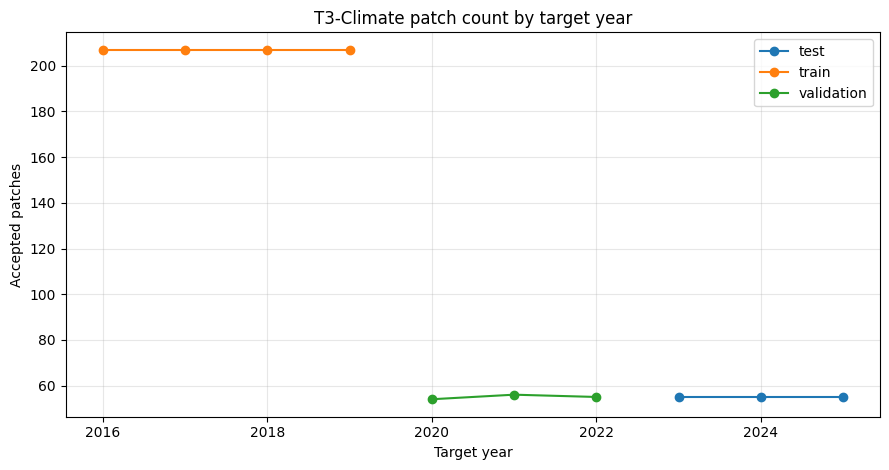

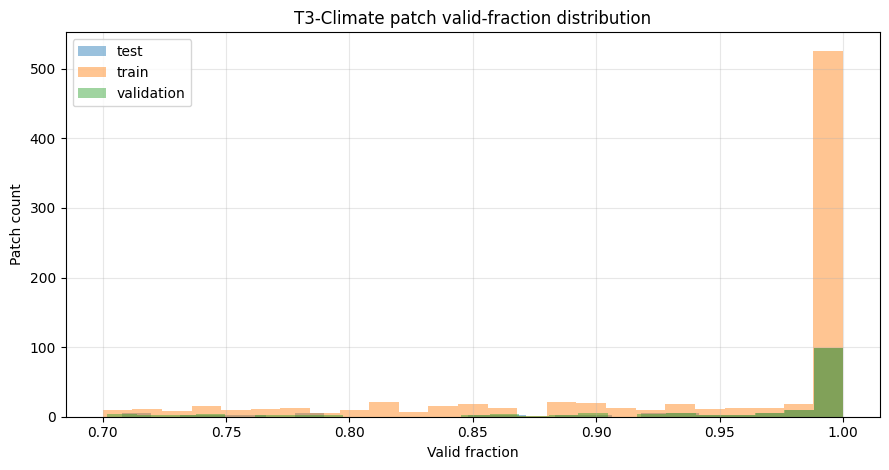

In [11]:
# ============================================================
# CELL 10 — Spatial coverage QC and figures
# ============================================================

coverage_qc = (
    patch_manifest_df
    .groupby(['split', 'target_year'])
    .agg(
        n_patches=('accepted_patch_id_in_year', 'count'),
        row0_min=('row0', 'min'),
        row0_max=('row0', 'max'),
        col0_min=('col0', 'min'),
        col0_max=('col0', 'max'),
        valid_fraction_min=('valid_fraction', 'min'),
        valid_fraction_mean=('valid_fraction', 'mean'),
        valid_fraction_max=('valid_fraction', 'max'),
    )
    .reset_index()
)

coverage_csv = DOC07_DIR / '07_patch_spatial_coverage_T3_Climate_2016_2025.csv'
coverage_qc.to_csv(coverage_csv, index=False)

display(coverage_qc)
print('Coverage QC saved:', coverage_csv)

fig, ax = plt.subplots(figsize=(9, 4.8))
for split, sdf in coverage_qc.groupby('split'):
    ax.plot(sdf['target_year'], sdf['n_patches'], marker='o', label=split)
ax.set_title('T3-Climate patch count by target year')
ax.set_xlabel('Target year')
ax.set_ylabel('Accepted patches')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig_path_counts = DOC07_FIG_DIR / '07_patch_counts_by_year_T3_Climate_2016_2025.png'
fig.savefig(fig_path_counts, dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8))
for split, sdf in patch_manifest_df.groupby('split'):
    ax.hist(sdf['valid_fraction'], bins=25, alpha=0.45, label=split)
ax.set_title('T3-Climate patch valid-fraction distribution')
ax.set_xlabel('Valid fraction')
ax.set_ylabel('Patch count')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig_path_valid = DOC07_FIG_DIR / '07_patch_valid_fraction_distribution_T3_Climate_2016_2025.png'
fig.savefig(fig_path_valid, dpi=160)
plt.show()


In [12]:
# ============================================================
# CELL 11 — Channel statistics by split
# ============================================================

channel_qc_rows = []
channel_names_reference = None

for _, row in split_summary_df.iterrows():
    split = row['split']
    path = Path(row['patch_npz_path'])
    with np.load(path, allow_pickle=False) as data:
        X = data['X'].astype(np.float32)
        mask = data['mask'].astype(np.uint8)
        channel_names = data['channel_names'].astype(str).tolist()

    if channel_names_reference is None:
        channel_names_reference = channel_names
    mask_bool = mask[..., 0].astype(bool)

    for i, ch in enumerate(channel_names):
        vals = X[..., i][mask_bool]
        group = 'spectral_T3' if i < 18 else 'climate_NASA_POWER'
        channel_qc_rows.append({
            'split': split,
            'channel_index': i,
            'channel_name': ch,
            'channel_group': group,
            'n_valid_values': int(vals.size),
            'mean': float(np.mean(vals)),
            'std': float(np.std(vals)),
            'min': float(np.min(vals)),
            'p01': float(np.percentile(vals, 1)),
            'p05': float(np.percentile(vals, 5)),
            'p50': float(np.percentile(vals, 50)),
            'p95': float(np.percentile(vals, 95)),
            'p99': float(np.percentile(vals, 99)),
            'max': float(np.max(vals)),
            'zero_fraction_inside_mask': float((vals == 0).mean()),
            'one_fraction_inside_mask': float((vals == 1).mean()),
        })

channel_qc_df = pd.DataFrame(channel_qc_rows)
channel_qc_csv = DOC07_DIR / '07_patch_channel_statistics_T3_Climate_2016_2025.csv'
channel_qc_df.to_csv(channel_qc_csv, index=False)

display(channel_qc_df)

# Strict [0,1] check only for spectral channels. Climate channels are train-only z-scores.
spectral_qc = channel_qc_df[channel_qc_df['channel_group'] == 'spectral_T3']
bad_spectral_range = spectral_qc[(spectral_qc['min'] < -1e-6) | (spectral_qc['max'] > 1.0 + 1e-6)]
if len(bad_spectral_range) > 0:
    display(bad_spectral_range)
    raise RuntimeError('At least one spectral channel is outside [0,1] inside patches.')

print('Channel QC approved. Spectral channels are inside [0,1]; climate channels are z-scored descriptors.')
print('Channel QC saved:', channel_qc_csv)


,split,channel_index,channel_name,channel_group,n_valid_values,mean,std,min,p01,p05,p50,p95,p99,max,zero_fraction_inside_mask,one_fraction_inside_mask
0,train,0,NDVI_Yminus3,spectral_T3,12835324,0.591516,0.276738,0.000000,0.000000,0.092592,0.626087,0.982094,1.000000,1.000000,0.014716,0.033319
1,train,1,NDMI_Yminus3,spectral_T3,12835324,0.439600,0.276185,0.000000,0.000000,0.048024,0.414901,0.917164,1.000000,1.000000,0.016156,0.024306
2,train,2,NDBI_Yminus3,spectral_T3,12835324,0.560400,0.276185,0.000000,0.000000,0.082836,0.585099,0.951976,1.000000,1.000000,0.024306,0.016156
3,train,3,UI_Yminus3,spectral_T3,12835324,0.470861,0.276513,0.000000,0.000000,0.042063,0.460629,0.926560,1.000000,1.000000,0.025829,0.012910
4,train,4,SAVI_Yminus3,spectral_T3,12835324,0.550197,0.263880,0.000000,0.000000,0.098341,0.560988,0.982895,1.000000,1.000000,0.013450,0.041304
5,train,5,BSI_Yminus3,spectral_T3,12835324,0.581802,0.288238,0.000000,0.000000,0.064862,0.617768,0.971089,1.000000,1.000000,0.025287,0.024962
6,train,6,NDVI_Yminus2,spectral_T3,12835324,0.573774,0.274467,0.000000,0.000000,0.079995,0.607589,0.966584,1.000000,1.000000,0.017310,0.024865
7,train,7,NDMI_Yminus2,spectral_T3,12835324,0.417003,0.270413,0.000000,0.000000,0.042155,0.384542,0.901377,1.000000,1.000000,0.018601,0.021966
8,train,8,NDBI_Yminus2,spectral_T3,12835324,0.582996,0.270413,0.000000,0.000000,0.098622,0.615458,0.957845,1.000000,1.000000,0.021966,0.018601
9,train,9,UI_Yminus2,spectral_T3,12835324,0.489609,0.274515,0.000000,0.000000,0.053285,0.483662,0.938940,1.000000,1.000000,0.023585,0.016344


Channel QC approved. Spectral channels are inside [0,1]; climate channels are z-scored descriptors.
Channel QC saved: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/07_patch_extraction_2016_2025/07_patch_channel_statistics_T3_Climate_2016_2025.csv


In [13]:
# ============================================================
# CELL 12 — Target y statistics and problematic patch diagnostics
# ============================================================

y_qc_rows = []

for _, row in split_summary_df.iterrows():
    split = row['split']
    path = Path(row['patch_npz_path'])
    with np.load(path, allow_pickle=False) as data:
        y = data['y'].astype(np.float32)
        mask = data['mask'].astype(np.uint8)
        target_year = data['target_year']

    mask_bool = mask[..., 0].astype(bool)
    vals = y[..., 0][mask_bool]
    y_qc_rows.append({
        'split': split,
        'years': ','.join(map(str, sorted(set(target_year.tolist())))),
        'n_valid_values': int(vals.size),
        'mean': float(np.mean(vals)),
        'std': float(np.std(vals)),
        'min': float(np.min(vals)),
        'p01': float(np.percentile(vals, 1)),
        'p05': float(np.percentile(vals, 5)),
        'p50': float(np.percentile(vals, 50)),
        'p95': float(np.percentile(vals, 95)),
        'p99': float(np.percentile(vals, 99)),
        'max': float(np.max(vals)),
    })

y_qc_df = pd.DataFrame(y_qc_rows)
y_qc_csv = DOC07_DIR / '07_patch_y_statistics_T3_Climate_2016_2025.csv'
y_qc_df.to_csv(y_qc_csv, index=False)

display(y_qc_df)
print('Y statistics saved:', y_qc_csv)

problematic = patch_manifest_df.copy()
low_valid = problematic[problematic['valid_fraction'] < (problematic['min_valid_fraction_threshold'] + 0.025)].copy()
extreme_y_mean = problematic[problematic['y_mean_inside_mask'].abs() > 2.0].copy()
low_y_std = problematic[problematic['y_std_inside_mask'] < 0.10].copy()

diagnostic_df = pd.DataFrame([
    {'criterion': 'valid_fraction_near_threshold', 'n_patches': int(len(low_valid)), 'fraction_of_all_patches': float(len(low_valid) / len(problematic))},
    {'criterion': 'abs_y_mean_gt_2', 'n_patches': int(len(extreme_y_mean)), 'fraction_of_all_patches': float(len(extreme_y_mean) / len(problematic))},
    {'criterion': 'y_std_lt_0_10', 'n_patches': int(len(low_y_std)), 'fraction_of_all_patches': float(len(low_y_std) / len(problematic))},
])

diagnostic_csv = DOC07_DIR / '07_patch_problematic_diagnostics_T3_Climate_2016_2025.csv'
diagnostic_df.to_csv(diagnostic_csv, index=False)
low_valid.to_csv(DOC07_DIR / '07_patch_low_valid_fraction_T3_Climate_2016_2025.csv', index=False)
extreme_y_mean.to_csv(DOC07_DIR / '07_patch_extreme_y_mean_T3_Climate_2016_2025.csv', index=False)
low_y_std.to_csv(DOC07_DIR / '07_patch_low_y_std_T3_Climate_2016_2025.csv', index=False)

display(diagnostic_df)
print('Problematic patch diagnostics saved:', diagnostic_csv)


,split,years,n_valid_values,mean,std,min,p01,p05,p50,p95,p99,max
0,train,"2016,2017,2018,2019",12835324,-0.162451,0.941140,-5.042657,-2.156005,-1.703338,-0.190777,1.379796,1.832463,3.907363
1,validation,"2020,2021,2022",2565869,-0.456864,0.972881,-5.421221,-2.194538,-1.833336,-0.621001,1.439501,2.011158,3.877722
2,test,"2023,2024,2025",2568058,-0.372383,0.977579,-5.448322,-2.092487,-1.767702,-0.507517,1.447124,2.104317,3.512708


Y statistics saved: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/07_patch_extraction_2016_2025/07_patch_y_statistics_T3_Climate_2016_2025.csv


,criterion,n_patches,fraction_of_all_patches
0,valid_fraction_near_threshold,33,0.028497
1,abs_y_mean_gt_2,13,0.011226
2,y_std_lt_0_10,0,0.000000


Problematic patch diagnostics saved: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/07_patch_extraction_2016_2025/07_patch_problematic_diagnostics_T3_Climate_2016_2025.csv


## Spatial diagnostics of patch sampling

This section creates two visual checks for the patch extraction procedure. The first figure shows where sampled patches fall in the full model domain. The second figure displays real examples of extracted patches for the input, target, and mask arrays. These figures are lightweight documentation products for GitHub and help reviewers verify that the sampling scheme is spatially coherent.

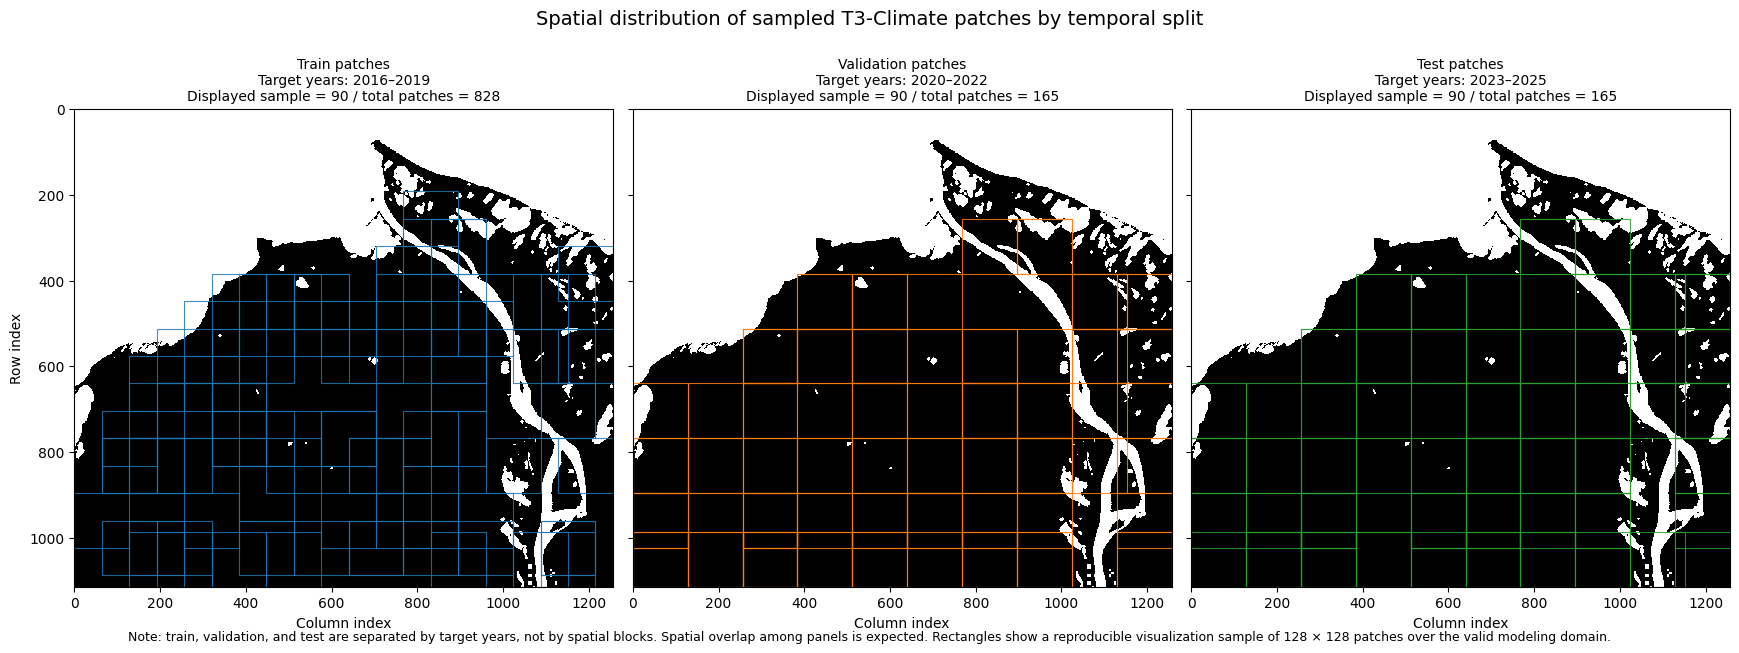

Patch spatial distribution figure: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/07_patch_extraction_2016_2025/figures/07_patch_spatial_distribution_by_split_T3_Climate_2016_2025.png
Patch spatial distribution note: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/07_patch_extraction_2016_2025/07_patch_spatial_distribution_note_T3_Climate_2016_2025.txt


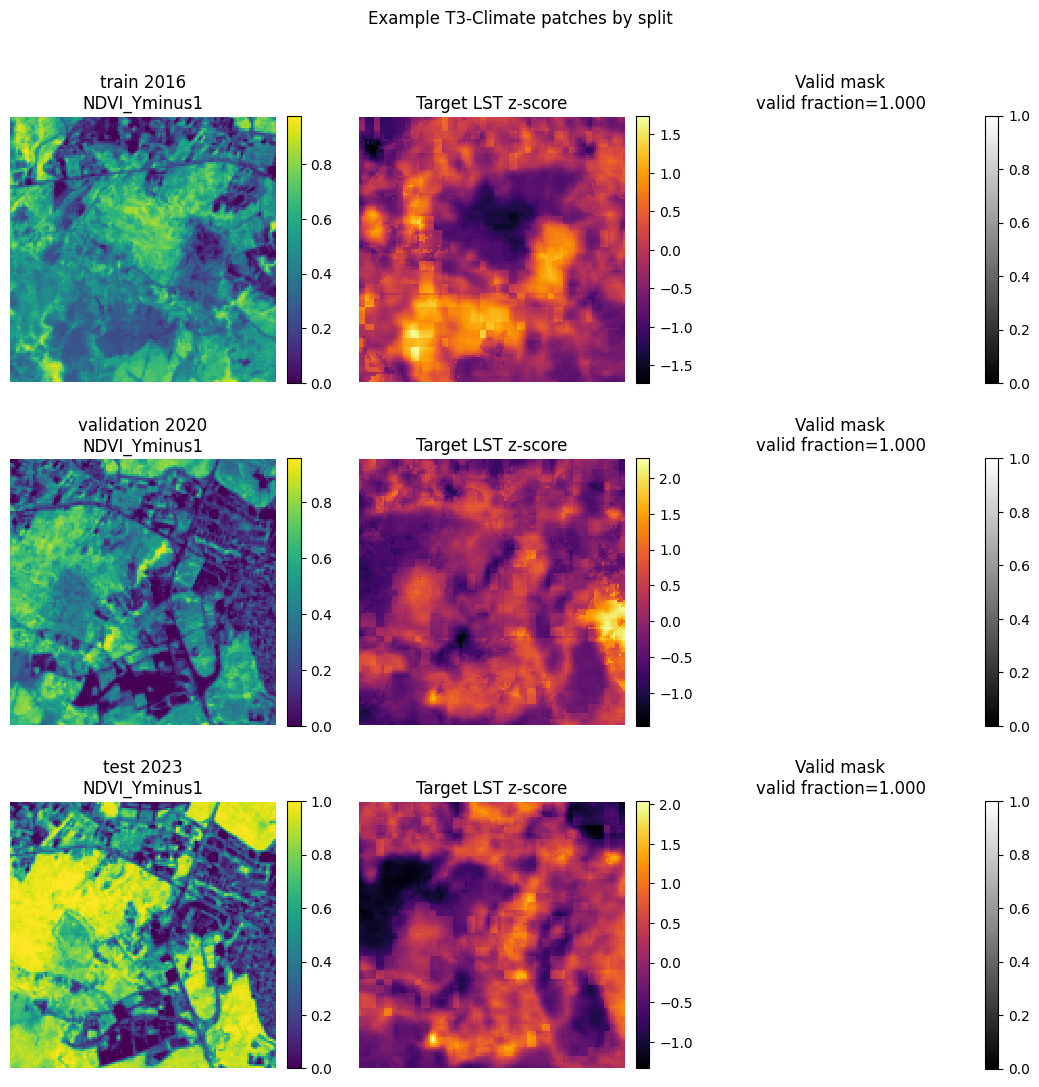

Patch spatial distribution figure: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/07_patch_extraction_2016_2025/figures/07_patch_spatial_distribution_by_split_T3_Climate_2016_2025.png
Patch example figure: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/07_patch_extraction_2016_2025/figures/07_patch_examples_T3_Climate_2016_2025.png
Patch visualization metadata: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/07_patch_extraction_2016_2025/07_patch_visualization_metadata_T3_Climate_2016_2025.json


In [16]:
# ============================================================
# CELL 13 — Spatial diagnostics: patch locations and examples
# ============================================================

from matplotlib.patches import Rectangle

# ------------------------------------------------------------
# Figure 1: spatial distribution of sampled patch windows
#         split into three panels for clearer interpretation
# ------------------------------------------------------------

# Use the first full-domain mask as a background to show the valid modeling domain.
first_tensor_path = Path(manifest_df.sort_values('target_year').iloc[0]['npz_path'])
X_ref, y_ref, mask_ref, channel_names_ref, _, _ = load_tensor_npz(first_tensor_path)
valid_background = mask_ref[..., 0].astype(float)

# Draw a reproducible subset of patch rectangles to keep the figure readable.
# IMPORTANT:
# This is a visualization sample, not necessarily the full patch set.
MAX_PATCHES_PER_SPLIT_FOR_MAP = 90

sampled_patch_rows = []
for split_name, sdf in patch_manifest_df.groupby('split'):
    n_sample = min(MAX_PATCHES_PER_SPLIT_FOR_MAP, len(sdf))
    sampled_patch_rows.append(
        sdf.sample(n=n_sample, random_state=RANDOM_SEED).copy()
    )

sampled_patches_df = pd.concat(sampled_patch_rows, ignore_index=True)

split_edge_styles = {
    'train': {
        'edgecolor': 'tab:blue',
        'title': 'Train patches',
        'years': 'Target years: 2016–2019'
    },
    'validation': {
        'edgecolor': 'tab:orange',
        'title': 'Validation patches',
        'years': 'Target years: 2020–2022'
    },
    'test': {
        'edgecolor': 'tab:green',
        'title': 'Test patches',
        'years': 'Target years: 2023–2025'
    },
}

split_order = ['train', 'validation', 'test']

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17.5, 5.8),
    sharex=True,
    sharey=True
)

for ax, split_name in zip(axes, split_order):
    ax.imshow(valid_background, cmap='Greys', interpolation='nearest')

    sdf = sampled_patches_df[sampled_patches_df['split'] == split_name].copy()
    style = split_edge_styles.get(
        split_name,
        {
            'edgecolor': 'tab:red',
            'title': split_name,
            'years': ''
        }
    )

    for _, pr in sdf.iterrows():
        rect = Rectangle(
            (float(pr['col0']), float(pr['row0'])),
            PATCH_SIZE,
            PATCH_SIZE,
            fill=False,
            linewidth=0.8,
            alpha=0.85,
            edgecolor=style['edgecolor'],
        )
        ax.add_patch(rect)

    n_display = len(sdf)
    n_total = int((patch_manifest_df['split'] == split_name).sum())

    ax.set_title(
        f"{style['title']}\n"
        f"{style['years']}\n"
        f"Displayed sample = {n_display} / total patches = {n_total}",
        fontsize=10
    )
    ax.set_xlabel('Column index')
    ax.set_xlim(0, REFERENCE_WIDTH)
    ax.set_ylim(REFERENCE_HEIGHT, 0)
    ax.grid(False)

axes[0].set_ylabel('Row index')

fig.suptitle(
    'Spatial distribution of sampled T3-Climate patches by temporal split',
    y=1.05,
    fontsize=14
)

# Methodological note inserted inside the figure.
fig.text(
    0.5,
    -0.02,
    (
        'Note: train, validation, and test are separated by target years, not by spatial blocks. '
        'Spatial overlap among panels is expected. Rectangles show a reproducible visualization '
        'sample of 128 × 128 patches over the valid modeling domain.'
    ),
    ha='center',
    va='top',
    fontsize=9
)

fig.tight_layout()

fig_path_patch_map = (
    DOC07_FIG_DIR /
    '07_patch_spatial_distribution_by_split_T3_Climate_2016_2025.png'
)
fig.savefig(fig_path_patch_map, dpi=180, bbox_inches='tight')
plt.show()

# Save a short methodological note for GitHub documentation.
patch_spatial_note = (
    "Spatial distribution of sampled T3-Climate patches by temporal split.\n\n"
    "Each panel shows a reproducible sample of 128 × 128 patch windows for one "
    "temporal split. The train, validation, and test partitions are separated by "
    "target years rather than by spatial blocks. Therefore, spatial overlap among "
    "the three panels is expected and does not indicate data leakage. The figure is "
    "intended as a visual quality-control diagnostic for patch extraction, not as a "
    "complete map of all generated patches.\n\n"
    "Temporal split:\n"
    "- Train: target years 2016–2019.\n"
    "- Validation: target years 2020–2022.\n"
    "- Test: target years 2023–2025.\n"
)

patch_spatial_note_path = (
    DOC07_DIR /
    '07_patch_spatial_distribution_note_T3_Climate_2016_2025.txt'
)

with open(patch_spatial_note_path, 'w', encoding='utf-8') as f:
    f.write(patch_spatial_note)

print('Patch spatial distribution figure:', fig_path_patch_map)
print('Patch spatial distribution note:', patch_spatial_note_path)

# ------------------------------------------------------------
# Figure 2: real patch examples by split
# ------------------------------------------------------------

def find_display_channel(channel_names):
    """Prefer an NDVI channel from the most recent antecedent year; otherwise use the first NDVI channel."""
    names = list(channel_names)
    preferred_tokens = ['Yminus1', 'Y_minus_1', 'lag1', 'lag_1', 'T3']
    for token in preferred_tokens:
        for i, name in enumerate(names):
            if 'NDVI' in name.upper() and token.upper() in name.upper():
                return i, name
    for i, name in enumerate(names):
        if 'NDVI' in name.upper():
            return i, name
    return 0, names[0]

example_rows = []
for split_name in ['train', 'validation', 'test']:
    sdf = patch_manifest_df[patch_manifest_df['split'] == split_name].copy()
    if len(sdf) == 0:
        continue
    # Select a representative high-quality patch close to the median valid fraction.
    median_valid = sdf['valid_fraction'].median()
    sdf['distance_to_median_valid_fraction'] = (sdf['valid_fraction'] - median_valid).abs()
    chosen = sdf.sort_values(['distance_to_median_valid_fraction', 'target_year']).iloc[0]
    example_rows.append(chosen)

if len(example_rows) == 0:
    raise RuntimeError('No patch examples available for visualization.')

fig, axes = plt.subplots(len(example_rows), 3, figsize=(10.5, 3.6 * len(example_rows)))
if len(example_rows) == 1:
    axes = np.array([axes])

for row_idx, pr in enumerate(example_rows):
    patch_npz_path = Path(pr['patch_npz_path'])
    patch_id = int(pr['accepted_patch_id_in_year'])

    with np.load(patch_npz_path, allow_pickle=False) as data:
        Xp = data['X'].astype(np.float32)
        yp = data['y'].astype(np.float32)
        mp = data['mask'].astype(np.uint8)
        channel_names = data['channel_names'].astype(str).tolist()

    ch_idx, ch_name = find_display_channel(channel_names)
    x_img = Xp[patch_id, :, :, ch_idx]
    y_img = yp[patch_id, :, :, 0]
    m_img = mp[patch_id, :, :, 0]

    split_name = pr['split']
    target_year = int(pr['target_year'])
    valid_fraction = float(pr['valid_fraction'])

    ax0, ax1, ax2 = axes[row_idx]
    im0 = ax0.imshow(x_img, cmap='viridis', interpolation='nearest')
    ax0.set_title(f'{split_name} {target_year}\n{ch_name}')
    ax0.axis('off')
    fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

    im1 = ax1.imshow(y_img, cmap='inferno', interpolation='nearest')
    ax1.set_title('Target LST z-score')
    ax1.axis('off')
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    im2 = ax2.imshow(m_img, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
    ax2.set_title(f'Valid mask\nvalid fraction={valid_fraction:.3f}')
    ax2.axis('off')
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

fig.suptitle('Example T3-Climate patches by split', y=1.01)
fig.tight_layout()
fig_path_patch_examples = DOC07_FIG_DIR / '07_patch_examples_T3_Climate_2016_2025.png'
fig.savefig(fig_path_patch_examples, dpi=180, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# Save visualization sampling metadata
# ------------------------------------------------------------

patch_visualization_metadata = {
    'spatial_distribution_figure': str(fig_path_patch_map),
    'example_patches_figure': str(fig_path_patch_examples),
    'max_patches_per_split_for_map': MAX_PATCHES_PER_SPLIT_FOR_MAP,
    'example_selection_rule': 'one representative patch per split, closest to the split median valid fraction',
    'example_rows': [
        {
            'split': str(pr['split']),
            'target_year': int(pr['target_year']),
            'patch_npz_path': str(pr['patch_npz_path']),
            'accepted_patch_id_in_year': int(pr['accepted_patch_id_in_year']),
            'row0': int(pr['row0']),
            'col0': int(pr['col0']),
            'valid_fraction': float(pr['valid_fraction']),
        }
        for pr in example_rows
    ],
}

patch_visualization_json = DOC07_DIR / '07_patch_visualization_metadata_T3_Climate_2016_2025.json'
with open(patch_visualization_json, 'w', encoding='utf-8') as f:
    json.dump(patch_visualization_metadata, f, ensure_ascii=False, indent=2)

print('Patch spatial distribution figure:', fig_path_patch_map)
print('Patch example figure:', fig_path_patch_examples)
print('Patch visualization metadata:', patch_visualization_json)


In [15]:
# ============================================================
# CELL 14 — Final summary, bitácora, and closure checks
# ============================================================

figures_manifest_df = pd.DataFrame([
    {'figure': fig_path_counts.name, 'path': str(fig_path_counts), 'description': 'Accepted patch count by target year and split.'},
    {'figure': fig_path_valid.name, 'path': str(fig_path_valid), 'description': 'Distribution of valid fraction among accepted patches.'},
    {'figure': fig_path_patch_map.name, 'path': str(fig_path_patch_map), 'description': 'Spatial distribution of sampled patch windows over the valid modeling domain.'},
    {'figure': fig_path_patch_examples.name, 'path': str(fig_path_patch_examples), 'description': 'Representative input, target, and mask patch examples by split.'},
])
figures_manifest_csv = DOC07_DIR / '07_patch_figures_manifest_T3_Climate_2016_2025.csv'
figures_manifest_df.to_csv(figures_manifest_csv, index=False)

summary = {
    'module': '07_patch_extraction',
    'product_name': PATCH_PRODUCT_NAME,
    'scientific_model_name': 'T3-Climate ConvLSTM-SE U-Net model',
    'created_at': datetime.now().isoformat(),
    'operational_period': '2013-2025',
    'target_years': TARGET_YEARS,
    'splits': SPLITS,
    'input_tensor_product': 'T3_M5B_spectral_nasa_power from Notebook 06',
    'patch_design': {
        'patch_size': PATCH_SIZE,
        'stride_by_split': STRIDE_BY_SPLIT,
        'min_valid_fraction_by_split': MIN_VALID_FRACTION_BY_SPLIT,
        'n_input_channels': EXPECTED_CHANNELS,
        'n_spectral_channels': 18,
        'n_climate_channels': 2,
        'target_channels': 1,
        'mask_channels': 1,
    },
    'methodological_note': (
        'These patches correspond to the final T3-Climate model. The first four spectral-only models use spectral-only T3 patches. '
        'NASA POWER channels are annual regional descriptors replicated spatially for tensor compatibility.'
    ),
    'outputs': {
        'heavy_patch_npz_dir': str(PATCH_NPZ_DIR),
        'documentation_dir': str(DOC07_DIR),
        'figures_dir': str(DOC07_FIG_DIR),
    },
    'github_upload_policy': {
        'upload_to_data_patches': [
            patch_manifest_csv.name,
            annual_qc_csv.name,
            split_summary_csv.name,
            reload_csv.name,
            coverage_csv.name,
            channel_qc_csv.name,
            y_qc_csv.name,
            diagnostic_csv.name,
            figures_manifest_csv.name,
            patch_visualization_json.name,
            '07_patch_extraction_summary_2016_2025.json',
            'bitacora_07_patch_extraction_2016_2025.md',
        ],
        'upload_to_docs_figures_patches': [fig_path_counts.name, fig_path_valid.name, fig_path_patch_map.name, fig_path_patch_examples.name],
        'do_not_upload': ['*.npz patch arrays', 'large tensor or raster products'],
    },
    'quality_control': {
        'n_annual_patch_files': int(len(annual_qc_df)),
        'n_split_patch_files': int(len(split_summary_df)),
        'total_patches': int(split_summary_df['n_patches'].sum()),
        'patches_by_split': {r['split']: int(r['n_patches']) for _, r in split_summary_df.iterrows()},
        'reload_ok': bool(reload_df['loaded_ok'].all()),
        'nan_detected': bool(reload_df['has_nan_X'].any() or reload_df['has_nan_y'].any()),
    },
}

summary_path = DOC07_DIR / '07_patch_extraction_summary_2016_2025.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

bitacora_text = f'''# Bitácora — Módulo 07: Patch extraction T3-Climate 2016–2025

**Proyecto:** Barranquilla_LST_2013_2026_Modeling
**Notebook:** `07_patch_extraction.ipynb`
**Producto:** `{PATCH_PRODUCT_NAME}`
**Modelo científico asociado:** T3-Climate ConvLSTM-SE U-Net model
**Fecha de ejecución:** {datetime.now().isoformat()}

## Objetivo

Extraer patches de entrenamiento, validación y prueba a partir de los tensores full-domain construidos en el Módulo 06.

## Insumo principal

```text
{SOURCE_TENSOR_MANIFEST}
```

## Diseño del patch

```text
patch_size = {PATCH_SIZE}
input_channels = {EXPECTED_CHANNELS}
18 canales espectrales T3 + 2 canales climáticos NASA POWER
```

## Partición temporal

```text
TRAIN      = {TRAIN_YEARS}
VALIDATION = {VALIDATION_YEARS}
TEST       = {TEST_YEARS}
```

## Salidas pesadas

```text
{PATCH_NPZ_DIR}
```

Estas salidas no deben subirse a GitHub.

## Salidas livianas para GitHub

```text
{DOC07_DIR}
```

Las figuras diagnósticas se encuentran en:

```text
{DOC07_FIG_DIR}
```

## Nota metodológica

Estos patches corresponden al modelo final T3-Climate ConvLSTM-SE U-Net. Los modelos espectrales M1–M4 deben evaluarse con patches T3 espectrales sin los dos canales climáticos. Esta separación evita confundir el efecto de arquitectura con el efecto de aumento climático.
'''

bitacora_path = DOC07_DIR / 'bitacora_07_patch_extraction_2016_2025.md'
bitacora_path.write_text(bitacora_text, encoding='utf-8')

expected_files = [
    patch_manifest_csv,
    annual_qc_csv,
    split_summary_csv,
    reload_csv,
    coverage_csv,
    channel_qc_csv,
    y_qc_csv,
    diagnostic_csv,
    figures_manifest_csv,
    patch_visualization_json,
    summary_path,
    bitacora_path,
]
missing_outputs = [str(p) for p in expected_files if not Path(p).exists()]
if missing_outputs:
    raise RuntimeError('Missing expected documentation outputs:\n' + '\n'.join(missing_outputs))

if reload_df['has_nan_X'].any() or reload_df['has_nan_y'].any():
    raise RuntimeError('NaN detected in consolidated patch products.')
if not (reload_df['n_channels'] == EXPECTED_CHANNELS).all():
    raise RuntimeError('Unexpected channel count in consolidated patch products.')

print('Módulo 07 completado correctamente.')
print('\nSubir a GitHub, carpeta data/patches/:')
for p in expected_files:
    print(' -', p.name)
print('\nSubir a GitHub, carpeta docs/figures/patches/:')
for p in [fig_path_counts, fig_path_valid, fig_path_patch_map, fig_path_patch_examples]:
    print(' -', p.name)
print('\nNo subir a GitHub:')
print(' -', PATCH_NPZ_DIR)


Módulo 07 completado correctamente.

Subir a GitHub, carpeta data/patches/:
 - 07_patch_manifest_T3_Climate_2016_2025.csv
 - 07_patch_annual_qc_T3_Climate_2016_2025.csv
 - 07_patch_summary_by_split_T3_Climate_2016_2025.csv
 - 07_patch_reload_validation_T3_Climate_2016_2025.csv
 - 07_patch_spatial_coverage_T3_Climate_2016_2025.csv
 - 07_patch_channel_statistics_T3_Climate_2016_2025.csv
 - 07_patch_y_statistics_T3_Climate_2016_2025.csv
 - 07_patch_problematic_diagnostics_T3_Climate_2016_2025.csv
 - 07_patch_figures_manifest_T3_Climate_2016_2025.csv
 - 07_patch_visualization_metadata_T3_Climate_2016_2025.json
 - 07_patch_extraction_summary_2016_2025.json
 - bitacora_07_patch_extraction_2016_2025.md

Subir a GitHub, carpeta docs/figures/patches/:
 - 07_patch_counts_by_year_T3_Climate_2016_2025.png
 - 07_patch_valid_fraction_distribution_T3_Climate_2016_2025.png
 - 07_patch_spatial_distribution_by_split_T3_Climate_2016_2025.png
 - 07_patch_examples_T3_Climate_2016_2025.png

No subir a GitHu